# 🏭 Decision Trees & Random Forests
## Industrial Automation — Chemical Process Fault Detection

---
> **Audience:** Process engineers & automation specialists with basic Python familiarity.  
> **Goal:** Understand how tree-based ML can detect equipment faults and abnormal process conditions in real time.

---

## 1. What Are Decision Trees? (Plain English)

Imagine a very experienced process engineer looking at a dashboard of sensor readings and asking a sequence of yes/no questions:

```
Is reactor temperature > 320 °C?
   YES → Is pressure > 8 bar?
              YES → ⚠️  FAULT: Runaway reaction risk
              NO  → ✅  Normal — high-temp batch mode
   NO  → Is feed flow rate < 50 L/min?
              YES → ⚠️  FAULT: Feed pump issue
              NO  → ✅  Normal operation
```

That logic tree **is** a Decision Tree. The model learns those thresholds automatically from historical process data.

### What is a Random Forest?
A **Random Forest** builds hundreds of such trees, each trained on a slightly different random sample of data and features. The final prediction is a **vote** across all trees — like polling hundreds of engineers instead of just one. This dramatically reduces the chance of a wrong diagnosis.

## 2. How Do They Learn? (The Core Idea)

At each split, the algorithm searches for the sensor threshold that best separates **normal** from **fault** states. It measures separation quality with **Gini Impurity** or **Information Gain**.

| Concept | Chemical Engineering Analogy |
|---|---|
| Feature | Sensor reading (T, P, flow, pH …) |
| Split threshold | Alarm setpoint learned from data |
| Leaf node | Process state label (Normal / Fault type) |
| Tree depth | Complexity of the diagnostic logic |
| Forest size | Size of the expert panel voting |

**Key point:** unlike rule-based SCADA alarms you write by hand, the model *discovers* the rules from data — including subtle multi-sensor interactions a human might miss.

## 3. Pros & Cons for Industrial Use

### ✅ Advantages
| Advantage | Why It Matters in a Plant |
|---|---|
| **Interpretable** | Operators can read the tree logic; no black-box concerns for safety audits |
| **Handles mixed data** | Works with temperatures, pressures, valve states (binary), batch IDs |
| **Robust to outliers** | Threshold splits are resistant to sensor spikes |
| **No feature scaling needed** | No need to normalise °C vs bar vs L/min |
| **Fast inference** | Microsecond predictions — suitable for real-time PLC integration |
| **Feature importance** | Tells you *which* sensors matter most for fault detection |

### ❌ Disadvantages
| Disadvantage | Mitigation |
|---|---|
| Single tree overfits easily | Use Random Forest or add pruning |
| Struggles with continuous smooth functions | Use gradient boosting for regression tasks |
| Needs labelled fault data | Use semi-supervised or synthetic fault generation |
| Forest less interpretable than one tree | Use SHAP values to explain individual predictions |
| Biased toward features with many unique values | Use feature importance with caution; apply MDI correction |

## 4. Best Use Cases in Chemical Engineering

1. **Process Fault Detection & Diagnosis (FDD)** — classify sensor signatures as Normal, Fouling, Leak, Valve Stiction, etc.
2. **Quality Prediction** — predict final product purity from upstream process variables mid-batch.
3. **Predictive Maintenance** — classify equipment health from vibration + temperature trends.
4. **Alarm Rationalisation** — learn which alarm combinations are actually meaningful vs. nuisance alarms.
5. **Grade Transition Optimisation** — classify whether current setpoints will achieve target grade.

---
**We will now build a complete Fault Detection system using a simulated CSTR (Continuous Stirred-Tank Reactor) dataset.**

## 5. Setup & Imports

In [1]:
# Install dependencies if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 6. Simulate a CSTR Process Dataset

We simulate 5 process states that a plant operator might encounter:

| Class | State | Description |
|---|---|---|
| 0 | Normal | Steady-state operation |
| 1 | Cooling Failure | Coolant flow drops → T rises |
| 2 | Feed Pump Fault | Feed flow drops → Concentration shifts |
| 3 | Fouling | Heat transfer degrades → T/P patterns change |
| 4 | Sensor Drift | Gradual offset in temperature reading |

In [2]:
def generate_cstr_data(n_samples=2000):
    """Generate synthetic CSTR sensor data for 5 process states."""
    n_per_class = n_samples // 5
    records = []

    states = {
        0: ('Normal',          dict(T=(250,8),  P=(5.0,0.2), F=(100,5), pH=(7.0,0.1), Cv=(80,3))),
        1: ('Cooling_Failure', dict(T=(310,12), P=(6.5,0.5), F=(100,5), pH=(6.8,0.2), Cv=(30,8))),
        2: ('Feed_Pump_Fault', dict(T=(240,10), P=(4.5,0.4), F=(40,10), pH=(7.5,0.3), Cv=(82,3))),
        3: ('Fouling',         dict(T=(268,9),  P=(7.2,0.6), F=(95,6),  pH=(7.0,0.1), Cv=(78,4))),
        4: ('Sensor_Drift',    dict(T=(255,6),  P=(5.1,0.2), F=(99,5),  pH=(7.1,0.1), Cv=(81,3))),
    }

    for label, (name, params) in states.items():
        for _ in range(n_per_class):
            row = {'state_label': label, 'state_name': name}
            for sensor, (mu, sigma) in params.items():
                row[sensor] = np.random.normal(mu, sigma)
            # Add a derived feature: heat balance residual
            row['HeatResidual'] = row['T'] * row['F'] / (row['Cv'] + 1e-6) + np.random.normal(0, 2)
            records.append(row)

    df = pd.DataFrame(records).sample(frac=1).reset_index(drop=True)
    return df

df = generate_cstr_data(2000)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['state_name'].value_counts())
df.head()

Dataset shape: (2000, 8)

Class distribution:
state_name
Cooling_Failure    400
Sensor_Drift       400
Fouling            400
Feed_Pump_Fault    400
Normal             400
Name: count, dtype: int64


,state_label,state_name,T,P,F,pH,Cv,HeatResidual
0,1,Cooling_Failure,316.129505,7.015290,96.710827,6.970905,21.264529,1439.533704
1,4,Sensor_Drift,260.907557,5.258134,102.936381,7.145958,87.053327,308.598477
2,3,Fouling,275.471452,7.423705,96.321136,7.103239,85.694054,307.727104
3,1,Cooling_Failure,306.550630,6.643664,99.772439,6.715153,25.441337,1202.848323
4,2,Feed_Pump_Fault,249.065442,4.528901,60.578112,7.068477,80.454487,187.280492


## 7. Exploratory Data Analysis

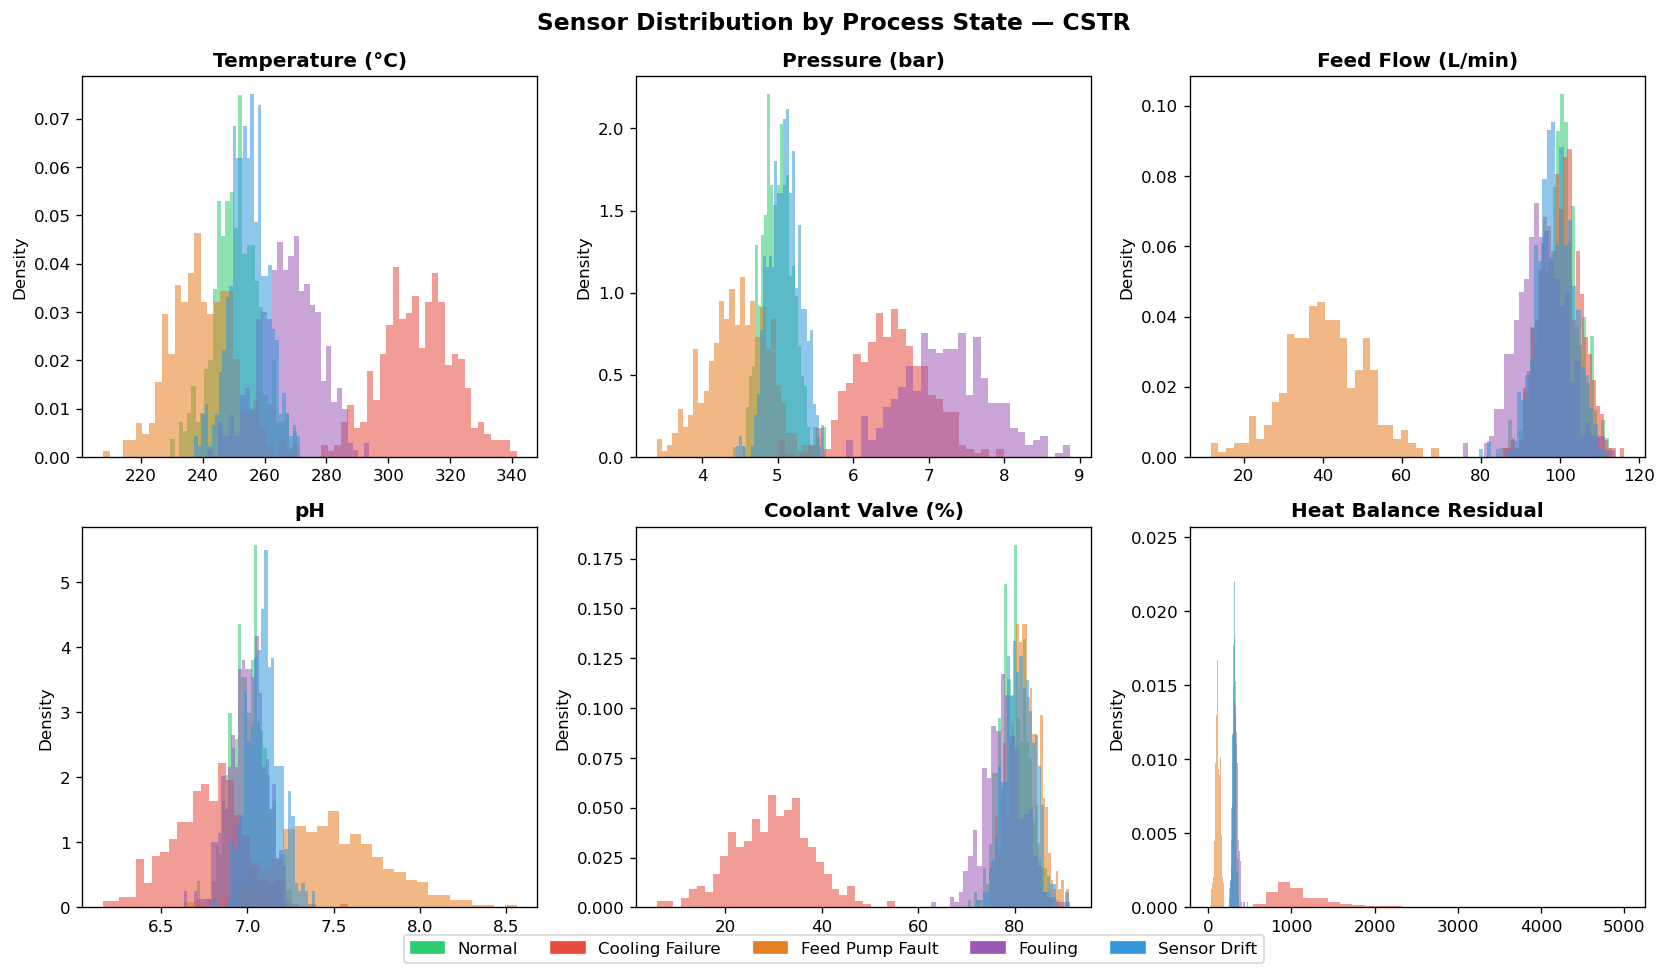

In [3]:
features = ['T', 'P', 'F', 'pH', 'Cv', 'HeatResidual']
sensor_names = {
    'T': 'Temperature (°C)', 'P': 'Pressure (bar)',
    'F': 'Feed Flow (L/min)', 'pH': 'pH',
    'Cv': 'Coolant Valve (%)', 'HeatResidual': 'Heat Balance Residual'
}

palette = {0:'#2ecc71', 1:'#e74c3c', 2:'#e67e22', 3:'#9b59b6', 4:'#3498db'}
state_colors = df['state_label'].map(palette)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Sensor Distribution by Process State — CSTR', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), features):
    for label, name in [(0,'Normal'),(1,'Cooling Failure'),(2,'Feed Pump'),(3,'Fouling'),(4,'Sensor Drift')]:
        subset = df[df['state_label']==label][feat]
        ax.hist(subset, bins=30, alpha=0.55, label=name, color=palette[label], density=True)
    ax.set_title(sensor_names[feat], fontweight='bold')
    ax.set_ylabel('Density')

handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(5)]
labels  = ['Normal','Cooling Failure','Feed Pump Fault','Fouling','Sensor Drift']
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.show()

## 8. Train a Single Decision Tree (Interpretable Baseline)

In [4]:
X = df[features]
y = df['state_label']
class_names = ['Normal','Cooling_Failure','Feed_Pump','Fouling','Sensor_Drift']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Shallow tree — fully interpretable, suitable for operator handbooks
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

dt_acc = dt.score(X_test, y_test)
print(f"Decision Tree Test Accuracy: {dt_acc:.3f}")
print("\n--- Extracted Rule Logic (first 20 lines) ---")
print(export_text(dt, feature_names=features, max_depth=3)[:1500])

Decision Tree Test Accuracy: 0.877

--- Extracted Rule Logic (first 20 lines) ---
|--- Cv <= 58.93
|   |--- class: 1
|--- Cv >  58.93
|   |--- HeatResidual <= 224.29
|   |   |--- class: 2
|   |--- HeatResidual >  224.29
|   |   |--- P <= 5.78
|   |   |   |--- pH <= 7.06
|   |   |   |   |--- class: 0
|   |   |   |--- pH >  7.06
|   |   |   |   |--- class: 4
|   |   |--- P >  5.78
|   |   |   |--- class: 3



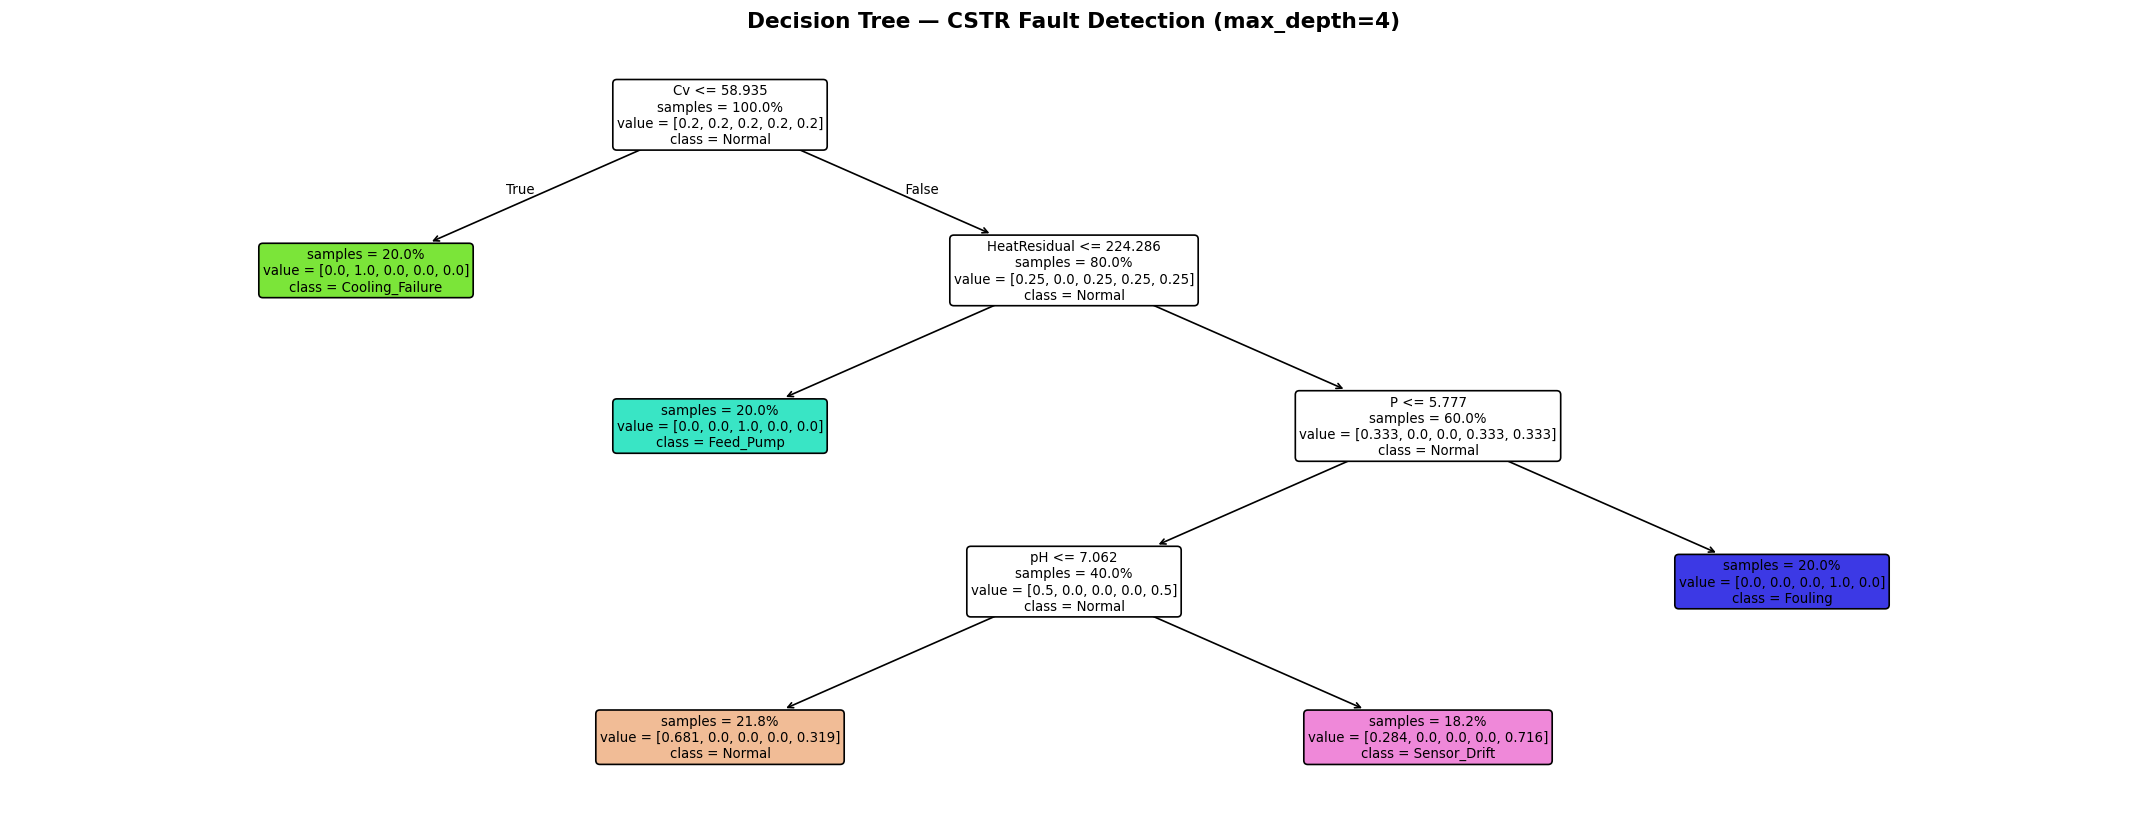


💡 Each leaf shows the class proportions. Darker = purer node.


In [5]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt, feature_names=features, class_names=class_names,
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True)
ax.set_title('Decision Tree — CSTR Fault Detection (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 Each leaf shows the class proportions. Darker = purer node.")

## 9. Train a Random Forest (Production-Grade Model)

In [6]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_acc = rf.score(X_test, y_test)
print(f"Random Forest Test Accuracy : {rf_acc:.3f}")
print(f"Decision Tree Test Accuracy : {dt_acc:.3f}")
print(f"Improvement from ensemble   : +{(rf_acc - dt_acc)*100:.1f} percentage points")

# Cross-validation for robustness estimate
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
print(f"\n5-Fold CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Random Forest Test Accuracy : 0.912
Decision Tree Test Accuracy : 0.877
Improvement from ensemble   : +3.5 percentage points

5-Fold CV F1-macro: 0.890 ± 0.014


Classification Report:
                 precision    recall  f1-score   support

         Normal       0.78      0.78      0.78        80
Cooling_Failure       1.00      1.00      1.00        80
      Feed_Pump       1.00      1.00      1.00        80
        Fouling       1.00      1.00      1.00        80
   Sensor_Drift       0.78      0.79      0.78        80

       accuracy                           0.91       400
      macro avg       0.91      0.91      0.91       400
   weighted avg       0.91      0.91      0.91       400



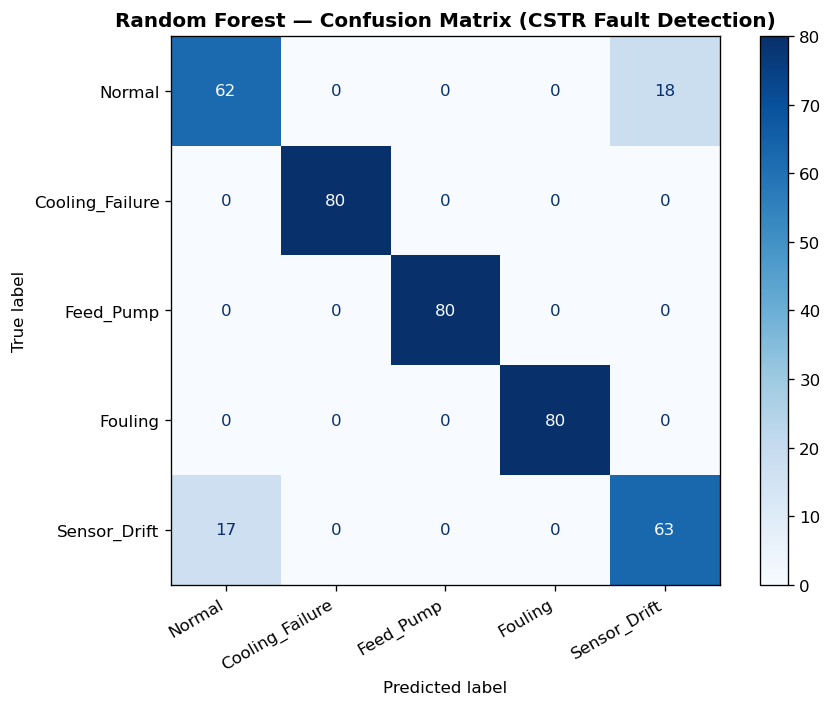

In [7]:
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (CSTR Fault Detection)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Feature Importance — Which Sensors Matter Most?

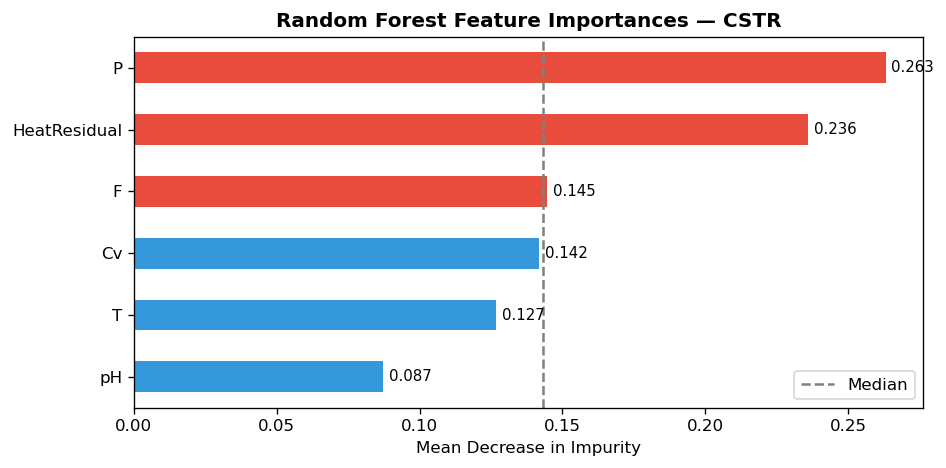


🔑 Insight: Top sensors to monitor for fault detection:
   Pressure (bar)                  importance = 0.263
   Heat Balance Residual           importance = 0.236
   Feed Flow (L/min)               importance = 0.145


In [8]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if v > importances.median() else '#3498db' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest Feature Importances — CSTR', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.axvline(importances.median(), color='grey', linestyle='--', label='Median')
ax.legend()
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n🔑 Insight: Top sensors to monitor for fault detection:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"   {sensor_names[feat]:30s}  importance = {imp:.3f}")

## 11. Real-Time Prediction Simulation

Simulate how the model would work embedded in a SCADA/DCS system.

In [9]:
def predict_process_state(T, P, F, pH, Cv, HeatResidual=None):
    """Predict CSTR process state from live sensor readings."""
    if HeatResidual is None:
        HeatResidual = T * F / (Cv + 1e-6)
    reading = pd.DataFrame([[T, P, F, pH, Cv, HeatResidual]], columns=features)
    pred_label = rf.predict(reading)[0]
    proba      = rf.predict_proba(reading)[0]
    confidence = proba.max()
    state_name = class_names[pred_label]

    status_icon = '✅' if pred_label == 0 else '⚠️ '
    print(f"{status_icon} Predicted State : {state_name}")
    print(f"   Confidence     : {confidence:.1%}")
    print("   Class probabilities:")
    for cn, p in zip(class_names, proba):
        bar = '█' * int(p * 20)
        print(f"     {cn:20s} {bar:<20s} {p:.2%}")

print("=" * 55)
print("SCENARIO A — Normal operation")
print("=" * 55)
predict_process_state(T=252, P=5.0, F=102, pH=7.0, Cv=80)

print("\n" + "=" * 55)
print("SCENARIO B — Cooling system failure")
print("=" * 55)
predict_process_state(T=318, P=6.8, F=100, pH=6.7, Cv=25)

SCENARIO A — Normal operation
✅ Predicted State : Normal
   Confidence     : 58.4%
   Class probabilities:
     Normal               ███████████          58.42%
     Cooling_Failure                           0.01%
     Feed_Pump                                 0.01%
     Fouling                                   0.25%
     Sensor_Drift         ████████             41.31%

SCENARIO B — Cooling system failure
⚠️  Predicted State : Cooling_Failure
   Confidence     : 100.0%
   Class probabilities:
     Normal                                    0.00%
     Cooling_Failure      ████████████████████ 100.00%
     Feed_Pump                                 0.00%
     Fouling                                   0.00%
     Sensor_Drift                              0.00%


## 12. Depth vs Accuracy Trade-off (Tuning Guide)

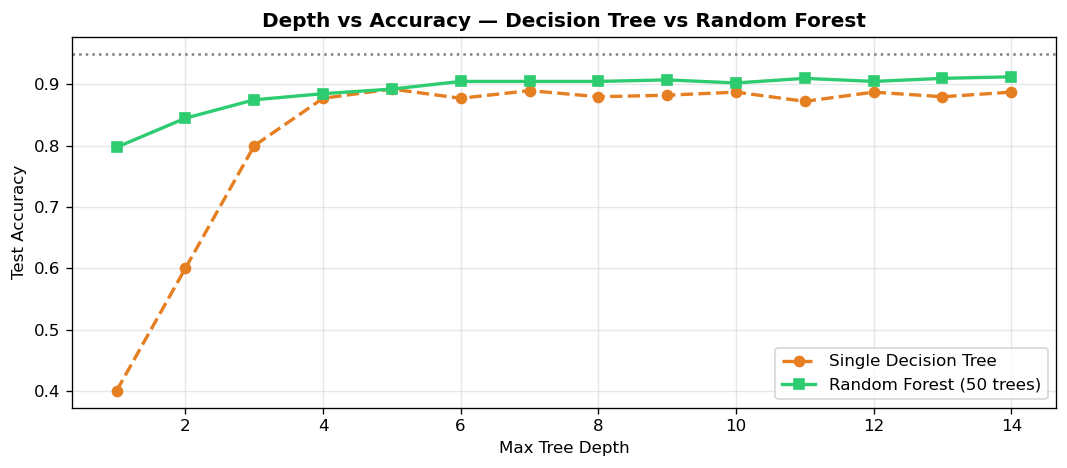


💡 Note: Single tree over-fits at depth > 8; Random Forest stays stable.


In [10]:
depths = range(1, 15)
dt_scores, rf_scores = [], []

for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    dt_scores.append(dt_d.score(X_test, y_test))
    rf_d = RandomForestClassifier(n_estimators=50, max_depth=d, n_jobs=-1, random_state=42).fit(X_train, y_train)
    rf_scores.append(rf_d.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, dt_scores, 'o--', color='#e67e22', label='Single Decision Tree', linewidth=2)
ax.plot(depths, rf_scores, 's-',  color='#2ecc71', label='Random Forest (50 trees)', linewidth=2)
ax.set_xlabel('Max Tree Depth')
ax.set_ylabel('Test Accuracy')
ax.set_title('Depth vs Accuracy — Decision Tree vs Random Forest', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(0.95, color='grey', linestyle=':', label='95% threshold')
plt.tight_layout()
plt.show()
print("\n💡 Note: Single tree over-fits at depth > 8; Random Forest stays stable.")

## 13. Key Takeaways for Chemical Process Engineers

| Question | Answer |
|---|---|
| **When to use a single tree?** | When operators need to read and audit the rules (safety-critical SIL classification) |
| **When to use Random Forest?** | When accuracy matters more than full interpretability (condition monitoring, soft sensors) |
| **How many sensors do I need?** | A good start is 5–15 key process variables; feature importance will tell you which ones to keep |
| **How much data is needed?** | Typically 500+ samples per fault class; use SMOTE or physics-based simulation for rare faults |
| **Can I deploy to a PLC/DCS?** | Yes — export the trained model to ONNX or a lookup table and call from IEC 61131-3 or Python OPC-UA client |
| **What about model drift?** | Retrain monthly or trigger on process changes; monitor prediction confidence as a drift signal |

---
**Next Steps:**
- Try replacing synthetic data with your plant's historian data (e.g., OSIsoft PI export)
- Explore `XGBoost` or `LightGBM` for even higher accuracy
- Use `SHAP` library for per-prediction explanations
- Wrap the model in a FastAPI microservice and connect via OPC-UA to your DCS